### Lab IV: Linear Models
### Answer all three sets of questions

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
3. Can linear regression be used for classification? Explain why, or why not.
4. If you have a high accuracy on testing but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

### Answers

1. What makes a model linear is the parameters created by the model, the betas. It weighs the variables together and gives a predicted value, assigning different weights to different variables. The thing that is linear is the coefficients, not necessarily the x's because those can be squared, logged, etc. The betas are purely just multipliers regardless of what you do to the x variables.
2. You interpret the coefficient for a dummy variable as the mean value of the y variable for each category of that encoded variable IF THERE IS NO INTERCEPT. If there IS an intercept, then the intercept for the dropped/reference group of the variable (the one that will be all 0s) will be that group's mean of the y variable, and the other categories will be the *difference* of the mean of that new category from the reference category's mean.
3. Linear regression can kind of be used for classification if you use it to predict an output value that is then subject to a cutoff value, but it's not directly capable of classification. They are also difficult to interpret in terms of probability if you have it predict a number since it's on a continuous scale that will go outside the bounds of 0 to 1, making it an invalid probability.
4. (I assume this is a typo, so I'll just answer both variants) If you have a high accuracy on training, but low on testing, the model is likely overfit to the training data and is not actually learning the patterns. With high accuracy on testing, but low on training, there may be some sort of data leakage in the test set.
5. Two ways to incorporate nonlinear relationships between y and x are logging certain features or squaring them. You can also put them to other powers like cubed and square root, depending on what makes it capture the relationship (feature engineering). You are also able to use bins to cut the continuous variable into intervals and then make a regression line for each section rather than the whole thing all at once.
6. The interpretation of the intercept is the predicted value of y when all x variables are 0. A slope coefficient for a variable is the average change in y given a one unit change in that slope, given all other variables are constant. The interpretation of the coefficient of a one-hot encoded variable is, with an intercept, the average difference in y from the reference group for that given group. Without an intercept, the coefficient is the average of that given group's value of the y variable.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv')
df = df.rename(columns = {'Neighbourhood ': 'Neighborhood'}) # There is a space at the end of the column name, and I changed the spelling to the American version of the word as well
df.head()

,Price,Review Scores Rating,Neighborhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


### Q1.1

In [17]:
# Compute average prices and scores by Neighborhood

df.groupby('Neighborhood')[['Price', 'Review Scores Rating']].mean()

,Price,Review Scores Rating
Neighborhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhatten is the most expensive on average, sitting around $183.66.

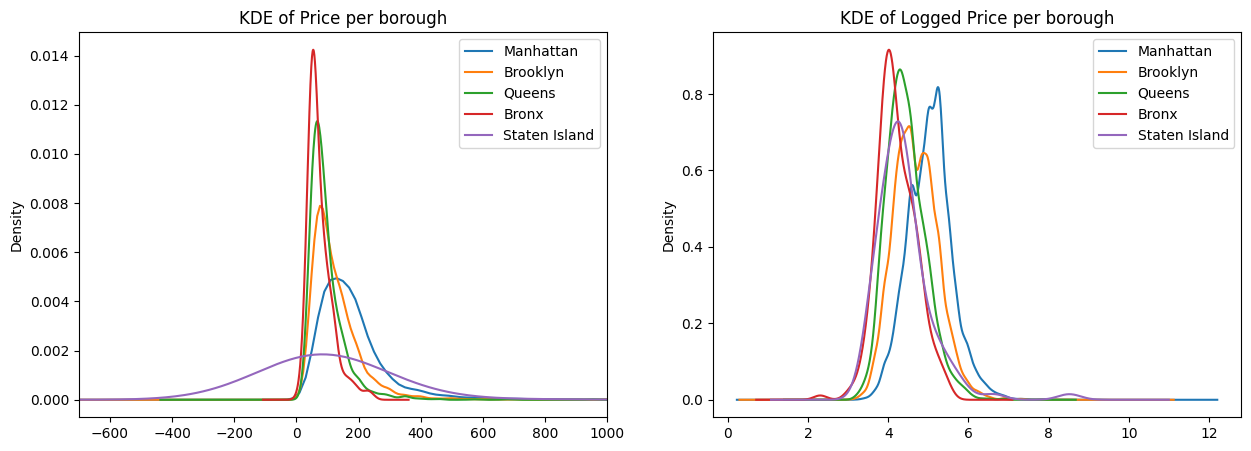

In [18]:
# KDE Plot of Price and log Price

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

for neighborhood in df['Neighborhood'].unique():
    subset = df[df['Neighborhood'] == neighborhood]
    subset['Price'].plot.kde(ax = axes[0], label = neighborhood)
    np.log(subset['Price']).plot.kde(ax = axes[1], label = neighborhood)
axes[0].set_title('KDE of Price per borough')
axes[0].legend()
axes[0].set_xlim(-700, 1000)
axes[1].set_title('KDE of Logged Price per borough')
axes[1].legend()
plt.show()

The plots seem right-skewed, especially without logging price.

### Q1.2

In [19]:
nb_dummies = pd.get_dummies(df['Neighborhood'], drop_first = False, prefix = 'Nb').astype(int)
nb_dummies

y = df['Price']

nb_no_int = LinearRegression(fit_intercept = False).fit(nb_dummies, y)
print(f'Coefficients:\n{pd.Series(nb_no_int.coef_, index = nb_dummies.columns)}')

Coefficients:
Nb_Bronx             75.276498
Nb_Brooklyn         127.747378
Nb_Manhattan        183.664286
Nb_Queens            96.857233
Nb_Staten Island    146.166667
dtype: float64


The coefficients are the same as the prices from the first table (the mean of y for each group of neighborhood). The coefficients in a regression of a continuous variable on one categorical variable are just the mean values of the y variable per category of the categorical variable.

### Q1.3

In [20]:
nb_dummies = pd.get_dummies(df['Neighborhood'], drop_first = True, prefix = 'Nb').astype(int)
nb_dummies

y = df['Price']

nb_with_int = LinearRegression(fit_intercept = True).fit(nb_dummies, y)
print(f'Coefficients:\n{pd.Series(nb_with_int.coef_, index = nb_dummies.columns)}')
print(f'Intercept: {nb_with_int.intercept_}')

Coefficients:
Nb_Brooklyn          52.470881
Nb_Manhattan        108.387789
Nb_Queens            21.580735
Nb_Staten Island     70.890169
dtype: float64
Intercept: 75.27649769585331


You have to handle the creation of dummies differently by changing drop_first to True instead of False since the model will have multicollinearity if you don't drop one of the categories when there is an intercept present since then the combination of the dummy variable columns will be linear combinations of the intercept column (since it's just 1s all the way down, and you would just sum across the categories to get that same thing). The intercept is 75.28, which is the average price for the Bronx category of neighborhood. The coefficients can be interpreted as the difference in average price from their respective neighborhood in comparison to the Bronx average since that's the reference category. This means that, on average, the average price is that much higher  than the average price in the Bronx. You can get the coefficients in part 2 from these new coefficients by just adding the intercept or the average from the Bronx category (since they're the same) to these new coefficients to get the old ones.

### Q1.4

In [21]:
# Create dummy variables
X4 = pd.get_dummies(df['Neighborhood'], drop_first = True).astype(int)
X4['Review Scores Rating'] = df['Review Scores Rating'].values

# Split the sample 80/20
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size = 0.2, random_state = 100)

In [22]:
# Regression of Price on Review Scores Rating and Neighborhood
model4 = LinearRegression().fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)

# R^2 and RMSE on test set
print(f'R^2 value on test set: {r2_score(y4_test, y4_pred)}')
print(f'RMSE value on test set: {np.sqrt(mean_squared_error(y4_test, y4_pred))}')

# Coefficient of Review Scores Rating
print(f'Coefficient of Review Scores Rating: {pd.Series(model4.coef_, index = X4.columns)["Review Scores Rating"]}')

# Find most expensive kind of property you can rent
print(f'The most expensive kind of property you can rent is a high-rated property in {pd.Series(model4.coef_, index = X4.columns).drop("Review Scores Rating").idxmax()} since that is the most expensive borough and increases in rating tend to increase price on average.')

R^2 value on test set: 0.06701086106947296
RMSE value on test set: 125.01092061382933
Coefficient of Review Scores Rating: 1.0322568767213625
The most expensive kind of property you can rent is a high-rated property in Manhattan since that is the most expensive borough and increases in rating tend to increase price on average.


### Q1.5

In [26]:
# Regression of Price on Review Scores Rating, Neighborhood, and Property Type
X5 = pd.get_dummies(df[['Neighborhood', 'Property Type', 'Review Scores Rating']], columns = ['Neighborhood', 'Property Type'], prefix = ['Nb', 'Pt'], drop_first = True).astype(int)
y = df['Price']

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y, test_size = 0.2, random_state = 100)

model5 = LinearRegression().fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)

# R^2 and RMSE on test set
print(f'R^2 value on test set: {r2_score(y5_test, y5_pred)}')
print(f'RMSE value on test set: {np.sqrt(mean_squared_error(y5_test, y5_pred))}')

# Coefficient of Review Scores Rating
print(f'Coefficient of Review Scores Rating: {pd.Series(model5.coef_, index = X5.columns)["Review Scores Rating"]}')

# Most expensive kind of property you can rent
model5_coefficients = pd.Series(model5.coef_, index = X5.columns)
nb_cols = [col for col in model5_coefficients.index if col.startswith('Nb_')]
pt_cols = [col for col in model5_coefficients.index if col.startswith('Pt_')]

max_borough = model5_coefficients[nb_cols].idxmax().replace('Nb_', '')
max_type = model5_coefficients[pt_cols].idxmax().replace('Pt_', '')

print(f'The most expensive kind of property you can rent is a high-rated property in {max_borough} of type {max_type}.')

R^2 value on test set: 0.07516232081019836
RMSE value on test set: 124.46361679209028
Coefficient of Review Scores Rating: 1.0158393371248176
The most expensive kind of property you can rent is a high-rated property in Manhattan of type Condominium.


### Q1.6

### What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient on `Review Scores Rating` in part 4 represents the effect that rating has on price while holding neighborhood constant, averaging out the other variables. Meanwhile, the coefficient in part 5 represents the effect of rating on price while holding both neighborhood and property type constant and averaging the other variables. The change in the value shows us that some of the coefficient that seemed to be from rating in part 4 was actually partially because of the property type and its effect. Otherwise, it would've remained the same.

### Q1.7 (Optional)

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

### Q2.1

In [32]:
cars = pd.read_csv('cars_hw.csv')
cars = cars.drop(columns = 'Unnamed: 0') # this is purely an index column we don't need
cars.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


<Axes: ylabel='Density'>

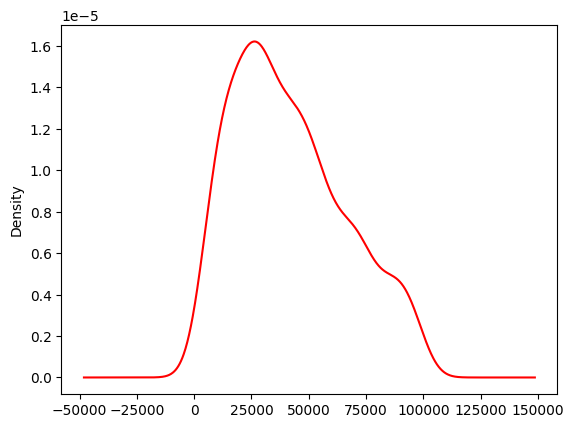

In [34]:
cars['Mileage_Run'].plot.kde(color = 'red')

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
